In [45]:
import pandas as pd
import sqlite3
import warnings
warnings.filterwarnings('ignore')

## 1

In [ ]:
conn=sqlite3.connect("../data/checking-logs.sqlite")

,uid,labname,first_commit_ts,first_view_ts
0,admin_1,None,None,2020-04-17 12:01:08.463179
1,admin_2,laba06,2020-05-19 08:22:39.690253,2020-04-28 19:09:01.362373
2,user_1,None,2020-04-26 19:06:51.939868,2020-04-26 21:53:59.624136
3,user_1,code_rvw,2020-04-26 19:06:58.949373,2020-04-26 21:53:59.624136
4,user_1,lab05s,2020-05-03 20:27:06.316718,2020-04-26 21:53:59.624136
5,user_1,laba04,2020-04-26 17:06:18.462708,2020-04-26 21:53:59.624136
6,user_1,laba04s,2020-04-26 17:12:11.843671,2020-04-26 21:53:59.624136
7,user_1,laba05,2020-05-02 19:15:18.540185,2020-04-26 21:53:59.624136
8,user_1,laba06,2020-05-17 16:26:35.268534,2020-04-26 21:53:59.624136
9,user_1,laba06s,2020-05-20 12:23:37.289724,2020-04-26 21:53:59.624136


## 2 & 3

In [ ]:
pd.read_sql_query("PRAGMA table_info(pageviews)", conn)

In [ ]:
test=pd.read_sql_query("SELECT * FROM test;", conn)

test.head(10)

## 4

In [47]:
deadlines=pd.read_sql_query("SELECT * FROM deadlines;", conn, parse_dates=['deadlines'])

deadlines.head(10)

,index,labs,deadlines
0,0,laba04,2020-04-26 23:59:59
1,1,laba04s,2020-04-26 23:59:59
2,2,laba05,2020-05-03 23:59:59
3,4,laba06,2020-05-24 23:59:59
4,5,laba06s,2020-05-24 23:59:59
5,3,project1,2020-05-16 23:59:59


In [48]:
deadlines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   index      6 non-null      int64         
 1   labs       6 non-null      object        
 2   deadlines  6 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 276.0+ bytes


In [49]:
# query="""
# SELECT t.uid, MIN((julianday(t.first_commit_ts) - julianday(dl.deadlines)) * 24) AS till_deadline
# FROM test AS t
# JOIN deadlines AS dl
#     ON dl.labs = t.labname
# WHERE t.labname='project1'
# GROUP BY t.uid;
# """

query = """
SELECT 
    d.uid,
    MIN((
        (dl.deadlines)
        - strftime('%s', substr(d.first_commit_ts, 1, 19)) ) / 3600.0
    )  AS min_delta_hours
FROM datamart AS d
JOIN deadlines AS dl 
    ON d.labname = dl.labs
WHERE d.labname != 'project1'
  AND d.uid LIKE 'user_%'
  AND d.first_commit_ts IS NOT NULL
GROUP BY d.uid;
"""

df_min=pd.read_sql_query(query, conn)
df_min

,uid,min_delta_hours
0,user_1,6.796667
1,user_10,39.368056
2,user_14,84.448611
3,user_17,34.643056
4,user_18,3.934167
5,user_19,32.729444
6,user_21,33.905278
7,user_25,2.867500
8,user_28,8.104167
9,user_3,60.511667


## 5

In [50]:
query = """
SELECT 
    d.uid,
    MAX((
        (dl.deadlines)
        - strftime('%s', substr(d.first_commit_ts, 1, 19)) ) / 3600.0
    ) 
        AS max_delta_hours
FROM datamart AS d
JOIN deadlines AS dl
    ON d.labname = dl.labs
WHERE d.labname != 'project1'
GROUP BY d.uid;
"""

df_max=pd.read_sql_query(query, conn)
df_max

,uid,max_delta_hours
0,None,469.804167
1,admin_2,135.622222
2,user_1,175.556667
3,user_10,132.341944
4,user_14,200.766389
5,user_17,81.591667
6,user_18,10.973611
7,user_19,148.916111
8,user_21,126.199722
9,user_25,150.870000


## 6

In [51]:
query = """
SELECT 
    d.uid,
    AVG((
        (dl.deadlines)
        - strftime('%s', substr(d.first_commit_ts, 1, 19)) ) / 3600.0
    ) 
        AS max_delta_hours
FROM datamart AS d
JOIN deadlines AS dl
    ON d.labname = dl.labs
WHERE d.labname != 'project1'
GROUP BY d.uid;
"""

df_avg=pd.read_sql_query(query, conn)
df_avg

,uid,max_delta_hours
0,None,105.644373
1,admin_2,135.622222
2,user_1,65.119778
3,user_10,75.242444
4,user_14,159.568796
5,user_17,62.207667
6,user_18,6.368148
7,user_19,99.440417
8,user_21,96.111181
9,user_25,93.474944


## 7

In [52]:
query_7="""
SELECT
    d.uid,

    AVG((
        (dl.deadlines)
        - strftime('%s', substr(d.first_commit_ts, 1, 19)) ) / 3600.0
    ) AS avg_diff,

    (SELECT COUNT(*)
     FROM pageviews pv
     WHERE pv.uid = d.uid
    ) AS pageviews

FROM datamart d
JOIN deadlines dl ON d.labname = dl.labs

WHERE d.labname != 'project1'
  AND d.uid LIKE 'user_%'
  AND d.first_commit_ts IS NOT NULL
  AND dl.deadlines IS NOT NULL

GROUP BY d.uid;

"""

diff_views = pd.read_sql_query(query_7, conn)
diff_views.head(10)

,uid,avg_diff,pageviews
0,user_1,65.119778,28
1,user_10,75.242444,89
2,user_14,159.568796,143
3,user_17,62.207667,47
4,user_18,6.368148,3
5,user_19,99.440417,16
6,user_21,96.111181,10
7,user_25,93.474944,179
8,user_28,86.793833,149
9,user_3,105.738222,317


In [53]:
diff_views['avg_diff'] = diff_views['avg_diff'].astype('float')
diff_views['pageviews']=diff_views['pageviews'].astype('int')

diff_views.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   uid        11 non-null     object 
 1   avg_diff   11 non-null     float64
 2   pageviews  11 non-null     int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 396.0+ bytes


In [54]:
corr=diff_views[['avg_diff', 'pageviews']].corr()
corr

,avg_diff,pageviews
avg_diff,1.000000,0.279143
pageviews,0.279143,1.000000


<Axes: xlabel='pageviews', ylabel='avg_diff'>

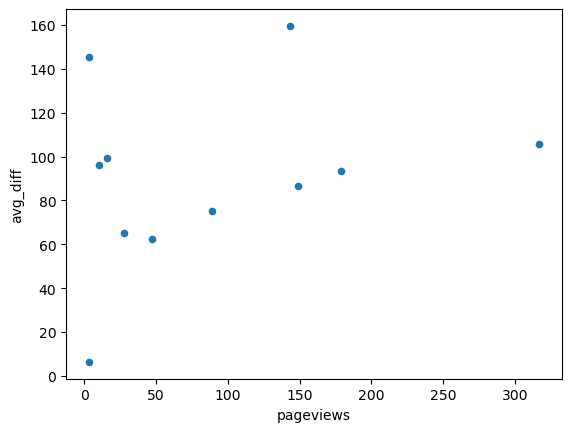

In [55]:
diff_views.plot.scatter(x='pageviews', y='avg_diff')

## 8

In [56]:
conn.close()